# TP1 · Task 2: Define the prediction and evaluation setting
## Classification of abnormal electric-vehicle charging sessions

**Course:** Mineração de Dados (MINDD), 2026/2027, 1st semester, ISEP / DEI

**Dataset:** educational version of the *China EV Charging Dataset* (Zhang et al., 2025). It has 441,077 charging sessions,
92 charging posts, 13 stations and 3 districts, from 2020 to 2021.

**What this notebook does.** Task 2 asks us to *define* the prediction problem and the way a solution will be judged,
**before** any model is optimised. So this notebook fits no model. It only builds the evaluation protocol (variables,
metrics, temporal folds, aggregation) and checks it with two simple baselines. Task 1 (`Task1.ipynb`) is reused, not repeated.

---
## 1. Setup

In [3]:
import json
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns
from IPython.display import display
from scipy.stats import wilcoxon

from sklearn.metrics import (average_precision_score, brier_score_loss, log_loss,
                             precision_recall_curve, roc_auc_score)

SEED = 42
DATA_PATH = Path("Charging_Data_educational.csv")
OUT_DIR = Path("prepared")
FIG_DIR = OUT_DIR / "figures_task2"
FIG_DIR.mkdir(parents=True, exist_ok=True)
TARGET = "is_Abnormal"
NORMAL_CAUSES = {"Charging ends normally", "User stops charging"}   # every other end cause is abnormal (Task 1, Section 5)

# Time boundaries. They come from Task 1 (Sections 7 and 11) and are justified again in Section 7 of this notebook.
BURN_IN_END = pd.Timestamp("2020-04-01")    # sessions before this date are not used for modelling
TEST_START = pd.Timestamp("2021-10-01")     # the final test period starts here and stays untouched
FOLD_BOUNDS = [("2020-10-01", "2021-01-01"),    # validation quarters of the four expanding-window folds
               ("2021-01-01", "2021-04-01"),
               ("2021-04-01", "2021-07-01"),
               ("2021-07-01", "2021-10-01")]
ALERT_BUDGETS = (0.05, 0.10, 0.20)          # share of sessions that may be flagged (operational metrics, Section 6)

sns.set_theme(style="whitegrid")
plt.rcParams.update({"figure.dpi": 110, "axes.titleweight": "bold", "axes.titlesize": 11})
pd.set_option("display.max_columns", 60)
pd.set_option("display.max_rows", 80)
pd.set_option("display.width", 200)
pd.set_option("display.max_colwidth", 140)
C_NORMAL, C_ABN, C_GREY, C_ORANGE, C_GREEN = "#4C72B0", "#C44E52", "#7F7F7F", "#E1A730", "#2a9d8f"

DECISIONS = []


def log_decision(section, topic, decision, evidence):
    """Store a decision together with its evidence (the full log is shown in Section 10)."""
    DECISIONS.append({"section": section, "topic": topic, "decision": decision, "evidence": evidence})


def savefig(fig, name):
    """Save a figure for the report and show it."""
    fig.savefig(FIG_DIR / f"{name}.png", bbox_inches="tight", dpi=150)
    plt.show()

---
## 2. Data and what we reuse from Task 1

We reuse four results of Task 1: the definition of the target, the burn-in period, the 29 features in 7 groups
(`prepared/feature_groups.json`) and the chronological layout (train until June 2021, validation 2021-Q3, test 2021-Q4).
Nothing is analysed again. We only load the few columns that the protocol needs, and the header of the full file, so that **all
47 original columns** can be classified in Section 4.

**Protecting the test period.** Right after loading, the burn-in and test rows are removed and only counted. From here on
the test sessions are not in memory, so no step of this notebook can use them by accident.

In [4]:
RENAME = {   # same short names as in Task 1
    "UserID": "user_id", "Charging Post ID": "post_id", "Location Information": "location", "District Name": "district",
    "Order creation time": "order_time", "Transaction power/kwh": "energy_kwh", "Electricity cost/Yuan": "electricity_cost",
    "Service charge/Yuan": "service_charge", "Transaction Amount/Yuan": "amount", "Actual Payment/Yuan": "actual_payment",
    "Start Time": "start_time", "End Time": "end_time", "Payment time": "payment_time",
    "Temperature(℃)": "temperature", "Relative Humidity(%)": "humidity", "Precipitation(mm)": "precipitation",
}
ALL_COLUMNS = pd.read_csv(DATA_PATH, nrows=0).columns.tolist()          # header only
FEATURE_GROUPS = json.loads((OUT_DIR / "feature_groups.json").read_text())   # written by Task 1

USECOLS = ["UserID", "Start Time", "End Time", "end_cause", "post_previous_abnormal_rate_7D", "user_previous_sessions_180D"]
df = pd.read_csv(DATA_PATH, usecols=USECOLS).rename(columns=RENAME)
df["end_cause"] = df["end_cause"].str.strip()
for col in ("start_time", "end_time"):
    df[col] = pd.to_datetime(df[col], format="%Y-%m-%d %H:%M:%S")
df[TARGET] = (~df["end_cause"].isin(NORMAL_CAUSES)).astype("int8")

n_total = len(df)
n_burn_in = int((df["start_time"] < BURN_IN_END).sum())
n_test = int((df["start_time"] >= TEST_START).sum())
df = df[(df["start_time"] >= BURN_IN_END) & (df["start_time"] < TEST_START)].reset_index(drop=True)   # the test rows disappear here

print(f"File: {n_total:,} sessions and {len(ALL_COLUMNS)} columns")
print(f"Burn-in (before {BURN_IN_END.date()}): {n_burn_in:,} sessions, not used")
print(f"Test (from {TEST_START.date()}): {n_test:,} sessions, removed from memory")
print(f"Development data ({df['start_time'].min().date()} to {df['start_time'].max().date()}): {len(df):,} sessions, "
      f"abnormal share {df[TARGET].mean():.2%}")
assert df["start_time"].max() < TEST_START

File: 441,077 sessions and 47 columns
Burn-in (before 2020-04-01): 14,017 sessions, not used
Test (from 2021-10-01): 80,081 sessions, removed from memory
Development data (2020-04-01 to 2021-09-30): 346,979 sessions, abnormal share 18.54%


**What we see:** the file has 441,077 sessions. After removing the burn-in (14,017) and the test period (80,081) we keep
**346,979 development sessions**, with an abnormal share of about 18.5%. These are the only rows that the folds in Section 7 can use.

---
## 3. The prediction problem

### 3.1 Formal definition

| Element | Definition |
|---------|------------|
| **Unit of observation** | One **charging session**: one row, i.e. one transaction of one account at one charging post, identified by its `Start Time`. |
| **Positive class** | `is_Abnormal = 1`: the session ends because of a fault or failure (13 of the 15 `end_cause` values: faults of the charging pile, DC output, connection, vehicle communication, BMS, and so on). |
| **Negative class** | `is_Abnormal = 0`: the session ends as intended, with `Charging ends normally` or `User stops charging`. |
| **Target** | Derived from `end_cause` (table below). The file has no `is_Abnormal` column. |
| **Prediction moment** | The **start of the session** (`Start Time`). The score is computed once, with only information known at that instant. Nothing that happens during or after the session may be used. |
| **Purpose** | **Preventive monitoring and maintenance prioritisation**: rank the starting sessions (and, through them, the posts) by risk of failure, so that the operator looks first at the riskiest ones. |
| **Meaning of "predicted abnormal"** | A **risk alert** raised when the session starts: *this session, on this post, is at increased risk of ending in a failure.* It is not a diagnosis and does not say which fault will occur. |

### 3.2 How the target is derived from `end_cause`

In [5]:
mapping = (df.groupby("end_cause").agg(sessions=("end_cause", "size"))
             .assign(share=lambda t: t["sessions"] / len(df),
                     is_Abnormal=lambda t: [0 if c in NORMAL_CAUSES else 1 for c in t.index])
             .sort_values("sessions", ascending=False))
display(mapping.style.format({"sessions": "{:,.0f}", "share": "{:.2%}"}))
print(f"Positive class: {df[TARGET].sum():,} sessions ({df[TARGET].mean():.2%}) | negative class: {(df[TARGET] == 0).sum():,} sessions "
      f"| imbalance about 1 : {(1 - df[TARGET].mean()) / df[TARGET].mean():.1f}")

,sessions,share,is_Abnormal
end_cause,,,
Charging ends normally,"159,504",45.97%,0
User stops charging,"123,139",35.49%,0
Other faults of the charging pile,"16,168",4.66%,1
DC Output Fault,"12,182",3.51%,1
Vehicle communications failure,"11,044",3.18%,1
BMS failure,"6,214",1.79%,1
Faulty charging connection,"6,016",1.73%,1
Failure of non-system control loop components and assemblies,"5,943",1.71%,1
Vehicle charging faults,"4,588",1.32%,1


Positive class: 64,336 sessions (18.54%) | negative class: 282,643 sessions | imbalance about 1 : 4.4


**What we see**
* The positive class is a **mix of 13 different failure causes**. The model predicts "any failure", not the type. Task 1 (§7.2)
  showed that this mix changes over time, so a model could learn one type of failure well and miss another.
* The two normal causes cover 81% of the sessions. `User stops charging` is a normal ending **by assumption**: it is the user's
  choice and not an equipment failure. Task 1 (§5.2) checked this against the dataset's own "previous abnormal" columns
  (our definition reproduces them in about 100% of the rows, the alternative does not), but the instructor has not confirmed it yet.
  If user stops were abnormal, the abnormal share would be 53.9% and the whole problem would change.

### 3.3 Purpose and operational meaning of an alert

What follows an alert decides which error hurts more (Section 5). We consider three possible actions, from the lightest to the
heaviest:

| Action after the alert | Who acts | Cost of acting |
|------------------------|----------|----------------|
| **Automated monitoring**: mark the session and its post on a dashboard, watch the next sessions | operator, automatic | very low |
| **Inspection / maintenance prioritisation**: remote diagnosis or a technician visit for the riskiest posts | maintenance team | medium, and limited by the number of technicians |
| **User intervention**: warn the driver or suggest another post before charging | platform, driver | low for the platform, but a false warning annoys the driver |

**Decision.** The main use we design for is the **first two actions**: a *ranked* list of risky sessions that an operator with
limited capacity can work through from the top. The third action is possible but needs a much higher confidence, so it is out of
the main scope.

In [6]:
log_decision("3", "Problem definition",
             "Unit = charging session; positive = abnormal ending (13 fault causes); prediction at Start Time; use = ranked risk alerts "
             "for preventive monitoring and maintenance prioritisation.",
             "Brief, Section 2; target mapping validated against the dataset's own history columns in Task 1 (§5.2), instructor confirmation pending.")

---
## 4. Which variables can be used?

The brief asks us to put **every** supplied variable into one of four categories and to justify each exclusion:

1. **eligible predictors**: genuinely known when the session starts;
2. **used only to build the target**;
3. **excluded because they are generated during or after the session**;
4. **excluded for another methodological reason**.

The table below is built in code, and an assertion checks that each of the 47 original columns appears exactly once. The
eligible set is read from the Task 1 file `prepared/feature_groups.json`, so the two tasks cannot drift apart.

In [7]:
INVERSE_RENAME = {short: original for original, short in RENAME.items()}
DERIVED = {"hour": "Start Time", "dow": "Start Time", "rain_flag": "Precipitation(mm)"}      # features built from one column (Task 1, §12)

features = [f for group in FEATURE_GROUPS["groups"].values() for f in group]
eligible_raw = {DERIVED.get(f, INVERSE_RENAME.get(f, f)) for f in features}
assert eligible_raw <= set(ALL_COLUMNS), eligible_raw - set(ALL_COLUMNS)

TARGET_ONLY = {"end_cause": ("Reason why the session ended. It *is* the outcome, so it can only define the label.",
                             "Task 1 §5: 15 values; 13 are faults and form the positive class.")}
POST_SESSION = {
    "Transaction power/kwh": "Energy delivered during the session.",
    "Electricity cost/Yuan": "Cost of the energy delivered during the session.",
    "Service charge/Yuan": "Fee computed on the finished transaction.",
    "Transaction Amount/Yuan": "Sum of electricity cost and service charge, known only at the end.",
    "Actual Payment/Yuan": "Amount paid after the session.",
    "End Time": "Moment the session ended. It is only used to know *when a label becomes available* (the purge in Section 7), never as a predictor.",
    "Payment time": "Recorded after the session (before the end in 20% of the rows, so it is not even a clean timestamp).",
}
POST_SESSION_EVIDENCE = "Task 1 §8.1: a single one of these columns reaches a univariate ROC-AUC of 0.82–0.85, above every start-time variable (best 0.77)."
OTHER = {
    "UserID": ("Key field: 56,115 different accounts, most with one or two sessions, and a large share of the validation sessions comes from "
               "accounts not seen in training. A model would memorise accounts, and it would identify people. The user's *history* is the "
               "legitimate substitute.", "Task 1 §9.5, §11; the share of unseen accounts per fold is in Section 7.2."),
    "Order creation time": ("Its availability at the prediction moment is not guaranteed: the order is stamped after the start in 57.2% of "
                            "the training sessions, by up to hours. Its lag to the start also reflects how the start went.", "Task 1 §8.2."),
    "electricity_price": ("Deterministic function of `tariff_period` (3 price levels for 7 periods), so it adds nothing.", "Task 1 §4.3, §12.2."),
    "post_previous_abnormal_1D": "Exact function of the session count and the smoothed rate: abnormal = rate × (sessions + 5) − 1.",
    "post_previous_abnormal_7D": "Exact function of the session count and the smoothed rate.",
    "post_previous_abnormal_30D": "Exact function of the session count and the smoothed rate.",
    "user_previous_abnormal_30D": "Exact function of the session count and the smoothed rate.",
    "user_previous_abnormal_180D": "Exact function of the session count and the smoothed rate.",
    "user_previous_abnormal_730D": "Exact function of the session count and the smoothed rate.",
    "post_no_previous_completed_session": "Constant after the burn-in: it is 1 only for the first session of each post, in January 2020.",
    "post_no_previous_completed_abnormal": "Constant after the burn-in (same reason).",
    "user_no_previous_completed_session": "Almost the same indicator as `is_new_user` (φ = 0.995, 0.1% of the rows differ).",
}
OTHER_EVIDENCE_DEFAULT = "Task 1 §12.2."

rows = []
for col in ALL_COLUMNS:
    if col in eligible_raw:
        group = next(g for g, cols in FEATURE_GROUPS["groups"].items()
                     if any(DERIVED.get(f, INVERSE_RENAME.get(f, f)) == col for f in cols))
        derived = [f for f, src in DERIVED.items() if src == col]
        reason = f"Known at the start ({group})" + (f"; enters as {', '.join(derived)}" if derived else "")
        rows.append((col, "1 eligible predictor", reason, "Task 1 §8.3"))
    elif col in TARGET_ONLY:
        rows.append((col, "2 target construction only", *TARGET_ONLY[col]))
    elif col in POST_SESSION:
        rows.append((col, "3 generated during/after the session", POST_SESSION[col], POST_SESSION_EVIDENCE))
    elif col in OTHER:
        reason, evidence = OTHER[col] if isinstance(OTHER[col], tuple) else (OTHER[col], OTHER_EVIDENCE_DEFAULT)
        rows.append((col, "4 excluded for another reason", reason, evidence))
    else:
        raise KeyError(f"column not classified: {col}")
classification = pd.DataFrame(rows, columns=["column", "category", "reason", "evidence"])
assert classification["column"].is_unique and len(classification) == len(ALL_COLUMNS) == 47

display(classification.groupby("category").size().rename("columns").to_frame())
display(classification[classification["category"] != "1 eligible predictor"].style.hide(axis="index")
        .set_properties(**{"text-align": "left", "white-space": "pre-wrap"}))

,columns
category,
1 eligible predictor,27
2 target construction only,1
3 generated during/after the session,7
4 excluded for another reason,12


column,category,reason,evidence
UserID,4 excluded for another reason,"Key field: 56,115 different accounts, most with one or two sessions, and a large share of the validation sessions comes from accounts not seen in training. A model would memorise accounts, and it would identify people. The user's *history* is the legitimate substitute.","Task 1 §9.5, §11; the share of unseen accounts per fold is in Section 7.2."
Order creation time,4 excluded for another reason,"Its availability at the prediction moment is not guaranteed: the order is stamped after the start in 57.2% of the training sessions, by up to hours. Its lag to the start also reflects how the start went.",Task 1 §8.2.
Transaction power/kwh,3 generated during/after the session,Energy delivered during the session.,"Task 1 §8.1: a single one of these columns reaches a univariate ROC-AUC of 0.82–0.85, above every start-time variable (best 0.77)."
Electricity cost/Yuan,3 generated during/after the session,Cost of the energy delivered during the session.,"Task 1 §8.1: a single one of these columns reaches a univariate ROC-AUC of 0.82–0.85, above every start-time variable (best 0.77)."
Service charge/Yuan,3 generated during/after the session,Fee computed on the finished transaction.,"Task 1 §8.1: a single one of these columns reaches a univariate ROC-AUC of 0.82–0.85, above every start-time variable (best 0.77)."
Transaction Amount/Yuan,3 generated during/after the session,"Sum of electricity cost and service charge, known only at the end.","Task 1 §8.1: a single one of these columns reaches a univariate ROC-AUC of 0.82–0.85, above every start-time variable (best 0.77)."
Actual Payment/Yuan,3 generated during/after the session,Amount paid after the session.,"Task 1 §8.1: a single one of these columns reaches a univariate ROC-AUC of 0.82–0.85, above every start-time variable (best 0.77)."
End Time,3 generated during/after the session,"Moment the session ended. It is only used to know *when a label becomes available* (the purge in Section 7), never as a predictor.","Task 1 §8.1: a single one of these columns reaches a univariate ROC-AUC of 0.82–0.85, above every start-time variable (best 0.77)."
Payment time,3 generated during/after the session,"Recorded after the session (before the end in 20% of the rows, so it is not even a clean timestamp).","Task 1 §8.1: a single one of these columns reaches a univariate ROC-AUC of 0.82–0.85, above every start-time variable (best 0.77)."
end_cause,2 target construction only,"Reason why the session ended. It *is* the outcome, so it can only define the label.",Task 1 §5: 15 values; 13 are faults and form the positive class.


**What we see**
* **27 of the 47 columns are eligible**. They produce the **29 features in 7 groups** of Task 1, because `Start Time` gives `hour`
  and `dow`, and `Precipitation` also gives `rain_flag`. The eligible columns are listed by group below.
* **7 columns** describe the session itself (energy, money, end and payment times) and **1** (`end_cause`) is the outcome. Their
  exclusion is not a matter of taste: they only exist after the session, so a model using them would not be able to run when the
  session starts.
* **12 columns** are excluded for other reasons: one **identifier** (`UserID`), one column whose **timing is uncertain**
  (`Order creation time`), and ten columns that are **redundant** (they carry no information that another column does not already
  have, so removing them loses nothing).

In [8]:
groups = pd.DataFrame([(g, len(cols), ", ".join(cols)) for g, cols in FEATURE_GROUPS["groups"].items()],
                      columns=["group", "features", "list"])
display(groups.style.hide(axis="index").set_properties(**{"text-align": "left", "white-space": "pre-wrap"}))
print("Total:", groups["features"].sum(), "features")
assert groups["features"].sum() == 29

group,features,list
calendar,2,"hour, dow"
tariff,1,tariff_period
location,3,"post_id, location, district"
weather,4,"temperature, humidity, precipitation, rain_flag"
post_history,8,"post_previous_sessions_1D, post_previous_sessions_7D, post_previous_sessions_30D, post_previous_abnormal_rate_1D, post_previous_abnormal_rate_7D, post_previous_abnormal_rate_30D, post_hours_since_previous_completed_session, post_hours_since_previous_completed_abnormal"
user_history,10,"is_new_user, user_previous_sessions_30D, user_previous_sessions_180D, user_previous_sessions_730D, user_previous_abnormal_rate_30D, user_previous_abnormal_rate_180D, user_previous_abnormal_rate_730D, user_days_since_previous_completed_session, user_days_since_previous_completed_abnormal, user_no_previous_completed_abnormal"
concurrency,1,user_active_sessions_at_start


Total: 29 features


**Assumptions that make the eligible set valid.** They are not facts that the data can prove, so we state them:

* **Weather** is treated as a *forecast* available at the start, as the brief says. In the data it is one daily value per district
  (Task 1 §4.3). If it were an observed daily total it would contain information from after the start.
* **History** attributes are taken as supplied. They use only sessions that had *finished before* the start (Task 1 §5.2 recomputed
  them from the timestamps). In production the history keeps updating, so in the validation and test periods the history of a session
  already contains the outcomes of earlier sessions of the same period that had finished. This is realistic, and we state it on purpose.
* **User history** needs the platform to identify the account at the start. If it cannot (a guest user), the user group is not
  available. This is the cold-start case, and it raises a privacy question: the user history is a behaviour profile.
* **`post_id`** is an identifier, but the post is known at the start and it is the most informative location level (Task 1 §9.1), so it
  stays eligible. Whether it adds value is a question for the ablation in Task 3.

In [9]:
log_decision("4", "Predictor set",
             "27 original columns are eligible (29 features in 7 groups). Excluded: 1 target-only column, 7 generated during or after the "
             "session, 12 for other reasons (identifier, uncertain timing, redundancy).",
             "Every one of the 47 columns appears once in the classification table; reasons and evidence per column in Section 4.")

---
## 5. The cost of the two errors

A **false positive** (FP) flags a normal session as risky. A **false negative** (FN) lets an abnormal session pass unnoticed.
Their consequences depend on what follows the alert (Section 3.3).

| | False positive (false alert) | False negative (missed failure) |
|---|------------------------------|----------------------------------|
| **Automated monitoring** | negligible: one more line on a dashboard | the failure is not marked, and the next sessions on that post are not watched |
| **Inspection / maintenance** | **a wasted inspection**. Technicians are limited, so every false alert takes time from a real problem | the faulty post stays in service. Failures **cluster**: Task 1 (§9.4) showed that the abnormal share goes from about 4% to about 60% between the lowest and highest recent-failure decile of a post, so one missed failure is followed by more |
| **User intervention** | an unnecessary warning or detour for a driver, which makes drivers stop trusting alerts | a driver spends time on a charge that fails (and may pay a service fee) |

**Which error matters more?** For one single event a **false negative costs more** than a false positive in the main use (monitoring and
maintenance): the action after an alert is cheap compared with a failure that continues unseen. But the number of false alerts is
**limited by capacity** (a long list of alerts becomes useless, a point known as alert fatigue). So neither error can simply be ignored:
the application needs a **good ranking** (the real failures near the top) and a **fixed number of alerts** that the operator can handle.

The exact cost ratio is not known. We write it as `c = cost(FN) / cost(FP)`. If the predicted probabilities are well calibrated, the best
cut-off is `t* = 1 / (1 + c)`: the higher c is, the lower the cut-off and the more sessions are flagged.

In [10]:
p = df[TARGET].mean()
cost_table = pd.DataFrame({"c = cost(FN) / cost(FP)": [1, 2, 3, 5, 10]})
cost_table["best probability cut-off t*"] = 1 / (1 + cost_table["c = cost(FN) / cost(FP)"])
cost_table["t* below the abnormal share?"] = np.where(cost_table["best probability cut-off t*"] < p, "yes", "no")
display(cost_table.style.hide(axis="index").format({"best probability cut-off t*": "{:.3f}"}))
c_break_even = (1 - p) / p
print(f"Abnormal share = {p:.3f}. A model with no skill (constant probability) should flag every session as soon as c > (1 - p) / p = {c_break_even:.1f}.")

c = cost(FN) / cost(FP),best probability cut-off t*,t* below the abnormal share?
1,0.500,no
2,0.333,no
3,0.250,no
5,0.167,yes
10,0.091,yes


Abnormal share = 0.185. A model with no skill (constant probability) should flag every session as soon as c > (1 - p) / p = 4.4.


**What we see**
* With equal costs (c = 1) only sessions with a risk of 50% or more are flagged. With c = 2 the cut-off falls to 0.33 and with c = 5 it is
  already **below the abnormal share** (0.185): when failures are much more expensive than false alerts, almost anything is worth flagging, and
  the alert list stops being selective. Beyond c ≈ 4.4 even a model without skill would flag every session.
* Since c is unknown, **fixing a single probability cut-off now would be arbitrary**. We choose two things instead: (i) metrics that
  judge the **ranking** and the **quality of the probabilities** (Section 6), and (ii) a **procedure** to choose the cut-off later
  (Section 7.4), based on the cost ratio *and* on the alert capacity.
* The abnormal share changes between periods (15.8%–21.1% across the folds of Section 7), so the same probability cut-off flags a different
  number of sessions in each period. For that reason the operational metrics are computed for a **fixed alert budget** (a fixed share of
  flagged sessions).

In [11]:
log_decision("5", "Error consequences",
             "A missed failure costs more per event than a false alert, but false alerts are capped by inspection capacity: evaluate the "
             "ranking and the result at a fixed alert budget. The cut-off is chosen later from the cost ratio and the capacity.",
             "Failures cluster by post (Task 1 §9.4); best cut-off t* = 1/(1 + c) falls below the abnormal share for c > 4.4.")

---
## 6. Evaluation metrics

The metrics are chosen **now**, before any model is optimised. The reasoning follows the slides: *the performance of a model depends on the
class distribution and on the cost of misclassifications*, and accuracy is not suitable for imbalanced classes or for classes with different costs.

| Metric | Role | What it measures | Why it fits this problem | Limitation here |
|--------|------|------------------|--------------------------|-----------------|
| **PR-AUC** (average precision) | **primary** | Area under the precision–recall curve: how precise the alerts are as we ask them to catch more failures | The positive class is the minority (about 18.5%) and both error types matter. It ignores true negatives, which are not what the operator cares about (slides: PR curve for rare positives and different costs) | Its no-skill value **equals the abnormal share**, and that share changes between periods. So it is always shown next to the baseline and as a **lift** (PR-AUC divided by the abnormal share), and models are compared **fold by fold** |
| **ROC-AUC** | complementary | Chance that a random abnormal session gets a higher score than a random normal one | Does not depend on the abnormal share, so it is comparable across periods and with the univariate AUCs of Task 1 | Can look optimistic with imbalanced classes, and says nothing about the top of the ranking (slides) |
| **Brier score** and **log-loss** | complementary | Quality of the predicted **probabilities** (calibration and sharpness) | The cut-off `t* = 1/(1+c)` of Section 5 is only valid if probabilities are calibrated. The extended Task 1 notebook (§14) also showed that class weights distort probabilities | Only for models that output probabilities. Both depend on the abnormal share |
| **Precision and recall at an alert budget q** | operational | Of the `q` share of sessions flagged (top of the ranking): how many are real failures (precision), and what share of all failures is caught (recall) | The alert budget is the practical limit (capacity) and it is the same for every model and every period | The budgets (5%, 10%, 20%) are assumptions, because the real capacity is unknown |
| **Correct alerts, false alerts and missed abnormal sessions per 1,000 sessions** | operational | TP, FP and FN at the alert budget, scaled to 1,000 sessions (as the brief suggests) | Converts the errors into workload: false alerts per 1,000 sessions is wasted inspections | Depends on the budget and on the abnormal share of the period |

**Stability measures (needed because a model should not be judged by its average only):** the metric **in every fold**, its standard deviation
across folds, the **worst fold**, the **trend** over time and the **number of folds** in which a model beats the baseline (details in Section 8).

**Metrics we do not use as primary or complementary:**
* **Accuracy** (the "accuracy paradox"): always answering "normal" is right about 81% of the time and catches no failure at all (shown in Section 9).
* **F1, balanced accuracy, Cohen's kappa and MCC** need a cut-off, which is not chosen yet, and F1 gives equal weight to both errors, which we
  argued is not our case. They can be reported once, at the final cut-off, in the modelling task.

In [12]:
def alert_metrics(y, score, budget, rng):
    """Flag the top `budget` share of sessions by score (ties broken at random). Return the operational measures."""
    n = len(y)
    k = int(round(budget * n))
    order = np.lexsort((rng.random(n), -score))          # sort by -score; ties are shuffled
    flagged = np.zeros(n, dtype=bool)
    flagged[order[:k]] = True
    tp = int((y[flagged] == 1).sum())
    return {"alerts per 1,000": 1000 * k / n,
            "correct alerts per 1,000": 1000 * tp / n,
            "false alerts per 1,000": 1000 * (k - tp) / n,
            "missed per 1,000": 1000 * (int(y.sum()) - tp) / n,
            "precision": tp / k, "recall": tp / y.sum()}


def evaluate_scores(y, score, probability=None, rng=None):
    """All Task 2 metrics for one set of predictions. `probability` (optional) is used for Brier score and log-loss."""
    rng = rng or np.random.default_rng(SEED)
    y = np.asarray(y)
    prevalence = y.mean()
    out = {"abnormal share": prevalence, "PR-AUC": average_precision_score(y, score)}
    out["lift"] = out["PR-AUC"] / prevalence
    out["ROC-AUC"] = roc_auc_score(y, score)
    if probability is not None:
        out["Brier"] = brier_score_loss(y, probability)
        out["log-loss"] = log_loss(y, np.clip(probability, 1e-6, 1 - 1e-6))
    for q in ALERT_BUDGETS:
        for name, value in alert_metrics(y, score, q, rng).items():
            out[f"{name} @{q:.0%}"] = value
    return out

In [13]:
log_decision("6", "Metrics",
             "Primary: PR-AUC. Complementary: ROC-AUC, Brier score, log-loss. Operational: precision, recall and correct / false / missed alerts per "
             "1,000 sessions at alert budgets of 5%, 10% and 20%. Stability: per-fold values, std, worst fold, trend, wins against the baseline. "
             "Accuracy, F1, kappa and MCC are not used for model comparison.",
             "Abnormal share ~18.5% with unequal error costs; the share moves between periods, so lift and fixed budgets are needed (Sections 5 and 7).")

---
## 7. Temporal evaluation design

### 7.1 Why not a random split, and which periods we use

The slides' random holdout, repeated holdout and K-fold cross-validation assume that any session could be swapped with any other. Here
that is false. Task 1 (§7) showed that volume, abnormal share, fault mix and the history attributes change over time, and a model will always
be used on **future** sessions. With a random split the validation set would contain sessions from the same weeks as the training set, and the
estimate would be too optimistic. The golden rule of the slides, *data used for evaluation cannot be used during development*, is applied in time:
**training observations always precede the observations that evaluate them.**

| Period | Dates (`Start Time`) | Use |
|--------|----------------------|-----|
| Burn-in | before 2020-04-01 | not used (history attributes still filling up, different failure mix; Task 1 §7) |
| **Development** | 2020-04-01 to 2021-09-30 | four expanding-window folds for model comparison, hyperparameter selection and cut-off selection |
| **Test** | from 2021-10-01 | untouched until every modelling decision is final |

### 7.2 The four folds

In [14]:
def temporal_folds(frame, bounds=FOLD_BOUNDS):
    """Expanding-window folds. For each validation quarter [lo, hi):
       train = development sessions that STARTED and ENDED before `lo`. The label of a session is only known when it ends,
               so sessions still running at `lo` are purged from the training set;
       valid = development sessions that started inside [lo, hi)."""
    folds = []
    for k, (lo, hi) in enumerate(bounds, start=1):
        lo, hi = pd.Timestamp(lo), pd.Timestamp(hi)
        started_before = frame["start_time"] < lo
        folds.append({"fold": k, "lo": lo, "hi": hi,
                      "train": frame.index[started_before & (frame["end_time"] < lo)],
                      "valid": frame.index[(frame["start_time"] >= lo) & (frame["start_time"] < hi)],
                      "purged": int((started_before & (frame["end_time"] >= lo)).sum())})
    return folds


FOLDS = temporal_folds(df)

# --- integrity checks of the temporal rules ---------------------------------------------------------------------------
for f in FOLDS:
    tr, va = df.loc[f["train"]], df.loc[f["valid"]]
    assert tr["start_time"].min() >= BURN_IN_END and tr["end_time"].max() < f["lo"]        # training labels known before validation starts
    assert va["start_time"].min() >= f["lo"] and va["start_time"].max() < f["hi"]
    assert np.intersect1d(f["train"], f["valid"]).size == 0                                  # no session in both parts
for a, b in zip(FOLDS[:-1], FOLDS[1:]):
    assert a["hi"] == b["lo"]                                                                # consecutive, non-overlapping validation quarters
    assert np.isin(a["train"], b["train"]).all()                                             # expanding window: each training set contains the previous one
assert FOLDS[-1]["hi"] == TEST_START and df["start_time"].max() < TEST_START                # nothing from the test period is used
print("All temporal integrity checks passed.")

rows = []
for f in FOLDS:
    tr, va = df.loc[f["train"]], df.loc[f["valid"]]
    rows.append({
        "fold": f["fold"],
        "training window": f"{BURN_IN_END.date()} to {(f['lo'] - pd.Timedelta(days=1)).date()}",
        "validation window": f"{f['lo'].date()} to {(f['hi'] - pd.Timedelta(days=1)).date()}",
        "training months": round((f["lo"] - BURN_IN_END).days / 30.4, 1),
        "train sessions": len(tr), "purged": f["purged"],
        "validation sessions": len(va), "validation abnormal": int(va[TARGET].sum()),
        "train abnormal share": tr[TARGET].mean(), "validation abnormal share": va[TARGET].mean(),
        "% validation sessions from accounts unseen in train": (~va["user_id"].isin(set(tr["user_id"]))).mean() * 100,
    })
fold_table = pd.DataFrame(rows).set_index("fold")
display(fold_table.style.format({"train sessions": "{:,.0f}", "validation sessions": "{:,.0f}", "validation abnormal": "{:,.0f}",
                                 "train abnormal share": "{:.1%}", "validation abnormal share": "{:.1%}",
                                 "% validation sessions from accounts unseen in train": "{:.1f}"}))

All temporal integrity checks passed.


,training window,validation window,training months,train sessions,purged,validation sessions,validation abnormal,train abnormal share,validation abnormal share,% validation sessions from accounts unseen in train
fold,,,,,,,,,,
1,2020-04-01 to 2020-09-30,2020-10-01 to 2020-12-31,6.000000,"111,470",37,"60,364","10,167",18.9%,16.8%,35.3
2,2020-04-01 to 2020-12-31,2021-01-01 to 2021-03-31,9.000000,"171,832",39,"41,797","6,611",18.2%,15.8%,36.3
3,2020-04-01 to 2021-03-31,2021-04-01 to 2021-06-30,12.000000,"213,641",27,"57,542","10,487",17.7%,18.2%,46.0
4,2020-04-01 to 2021-06-30,2021-07-01 to 2021-09-30,15.000000,"271,182",28,"75,769","16,016",17.8%,21.1%,39.9


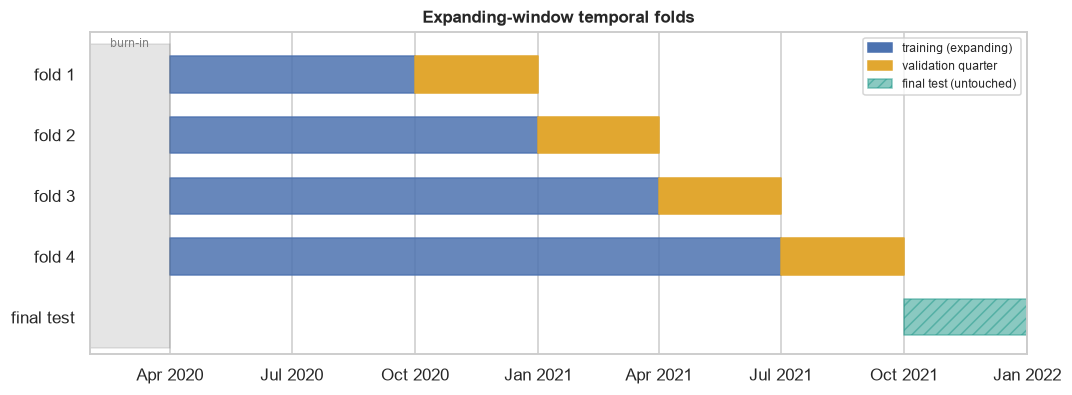

In [15]:
fig, ax = plt.subplots(figsize=(11, 3.8))
d2n = mdates.date2num
start_all, end_all = d2n(BURN_IN_END - pd.Timedelta(days=60)), d2n(pd.Timestamp("2022-01-01"))
n_folds = len(FOLDS)
for i, f in enumerate(FOLDS):
    y0 = n_folds - i                                                   # fold 1 on top ... fold 4 above the test row
    ax.broken_barh([(d2n(BURN_IN_END), d2n(f["lo"]) - d2n(BURN_IN_END))], (y0 - 0.3, 0.6), color=C_NORMAL, alpha=.85)
    ax.broken_barh([(d2n(f["lo"]), d2n(f["hi"]) - d2n(f["lo"]))], (y0 - 0.3, 0.6), color=C_ORANGE)
ax.broken_barh([(d2n(TEST_START), end_all - d2n(TEST_START))], (-0.3, 0.6), color=C_GREEN, hatch="///", alpha=.55)    # test row
ax.broken_barh([(start_all, d2n(BURN_IN_END) - start_all)], (-0.5, n_folds + 1.0), color=C_GREY, alpha=.2)
ax.set_yticks(list(range(n_folds, 0, -1)) + [0])
ax.set_yticklabels([f"fold {f['fold']}" for f in FOLDS] + ["final test"])
ax.set_ylim(-0.6, n_folds + 0.7)
ax.xaxis_date(); ax.xaxis.set_major_formatter(mdates.DateFormatter("%b %Y")); ax.set_xlim(start_all, end_all)
ax.text(d2n(BURN_IN_END) - 30, n_folds + 0.45, "burn-in", ha="center", fontsize=8, color=C_GREY)
ax.legend(handles=[plt.Rectangle((0, 0), 1, 1, color=C_NORMAL), plt.Rectangle((0, 0), 1, 1, color=C_ORANGE),
                   plt.Rectangle((0, 0), 1, 1, color=C_GREEN, alpha=.55, hatch="///")],
          labels=["training (expanding)", "validation quarter", "final test (untouched)"], loc="upper right", fontsize=8)
ax.set_title("Expanding-window temporal folds")
ax.grid(axis="y", visible=False)
savefig(fig, "07_2_temporal_folds")

**What we see**
* **Four quarterly folds.** Each one trains on every labelled session before its validation quarter and validates on the next three months.
  Task 1 planned three expanding-window folds inside the training period plus a separate validation quarter (2021-Q3). Here the validation
  quarter is simply the **fourth fold** of the same scheme. This gives four estimates instead of three, puts the most recent quarter (the closest to the
  test) into model selection, and keeps the test untouched.
* **Purge.** Only 27–39 training sessions per fold would still be running at the boundary, and they are removed because their label would not exist yet.
* **Fold sizes differ.** Validation folds have 41,797 to 75,769 sessions (traffic grows, and February–March 2021 is quiet), and the training
  window grows from 111k to 271k sessions, i.e. from 6 to 15 months. Early folds therefore train on **less data** and **do not include a full winter**.
  Their scores are expected to be a little pessimistic, and fold 1 validates in a season that the model has not seen.
* **The abnormal share changes by fold** (15.8% to 21.1% in validation). This is the reason for the lift and for the paired comparisons of Section 8.
* **Unseen accounts.** 35%–46% of the validation sessions in each fold come from accounts that are not in the training window. A model that
  depended on account identity would have no information about a large part of the sessions, which confirms excluding `UserID` (Section 4).

**Why these boundaries and this number of folds**
* *Quarters*: one quarter is about one season, large enough for a stable estimate (every validation fold has 6,600 or more abnormal sessions) and
  short enough to see change over time. The boundaries are calendar quarters, **fixed before looking at any model result**.
* *Four folds*: an earlier fold would train on fewer than six months of data, which is not a useful model. Monthly folds would give 12 noisy
  estimates of 15–25k sessions each and make the early folds even smaller. Four folds are the compromise, and they are enough to see whether
  the performance is stable, but not enough for a precise estimate of its variability (Section 8).
* *Expanding* (and not a fixed-size rolling window): the model that will be deployed is trained on **all** the past, so the folds copy that.

In [16]:
log_decision("7", "Temporal strategy",
             "Burn-in before 2020-04-01; development 2020-04-01 to 2021-09-30 with four expanding-window folds (validation = consecutive quarters "
             "2020-Q4 to 2021-Q3); test from 2021-10-01 untouched. No random splitting.",
             "Prevalence, volume and fault mix change over time (Task 1 §7); fold sizes 41.8k–75.8k validation, 111k–271k training; every fold has ≥ 6,600 abnormal sessions.")
log_decision("7", "Purge", "Training sessions that end after the validation start are removed from that fold's training set.",
             "A label exists only when the session ends (up to 24 h later); 27–39 sessions per fold.")

### 7.3 How preprocessing is fitted inside each training fold

Task 1 listed the operations that **learn from data** (imputation values, scaling, caps, category vocabularies, encoders, feature selection, resampling).
The rule for every model compared in the next task is:

1. For each fold, a **new** pipeline (preprocessing and model together) is created and **fitted on that fold's training rows only**.
2. The fitted pipeline is applied **unchanged** to that fold's validation rows. Nothing is re-fitted on them.
3. Class weights or resampling, if used, touch the training rows only. The validation rows keep their natural class distribution, so the metrics
   describe the future situation (slides: evaluate on the initial distribution).
4. A configuration of hyperparameters is judged by its average over the four folds (Section 8). If an inner search is needed, it uses only an
   earlier part of the fold's training window, never the validation quarter.
5. Categories never seen in the training rows are handled by the encoder and not by looking at the validation rows. The seed is fixed (`SEED = 42`).

The table shows what is at stake: the values that a preprocessing step would learn are different in each fold, and different again if they
are computed on all development data, which contains the future of the early folds.

In [17]:
demo = []
for f in FOLDS:
    tr = df.loc[f["train"]]
    demo.append({"fold": f["fold"], "prior (abnormal share)": tr[TARGET].mean(),
                 "median user_previous_sessions_180D": tr["user_previous_sessions_180D"].median(),
                 "99.9th percentile user_previous_sessions_180D": tr["user_previous_sessions_180D"].quantile(0.999)})
demo.append({"fold": "all development data", "prior (abnormal share)": df[TARGET].mean(),
             "median user_previous_sessions_180D": df["user_previous_sessions_180D"].median(),
             "99.9th percentile user_previous_sessions_180D": df["user_previous_sessions_180D"].quantile(0.999)})
display(pd.DataFrame(demo).set_index("fold").style.format({"prior (abnormal share)": "{:.4f}", "median user_previous_sessions_180D": "{:.1f}",
                                                              "99.9th percentile user_previous_sessions_180D": "{:,.0f}"}))

,prior (abnormal share),median user_previous_sessions_180D,99.9th percentile user_previous_sessions_180D
fold,,,
1,0.1888,22.0,"6,461"
2,0.1817,24.0,"6,422"
3,0.1771,24.0,"6,398"
4,0.1782,21.0,"6,376"
all development data,0.1854,20.0,"6,330"


**What we see:** the values change from fold to fold (class prior 17.7%–18.9%, 99.9th percentile of the 180-day user count 6,376–6,461) and the
"all data" values (18.5% and 6,330) match none of them. For these particular statistics the differences are **small**, because the distributions are fairly
stable after the burn-in. The rule is not about the size of this effect: fitting once on all development data would let the early folds *see* later sessions,
and the effect would be much larger for steps that use the **target** (resampling, target encoding, feature selection). Fitting inside each fold avoids
the problem for every step, at the price of one fit per fold.

### 7.4 How the decision threshold will be selected

Models will produce a score or probability for the validation rows of each fold (**out-of-fold predictions**). The operating point is chosen on the
four out-of-fold prediction sets together, never on the test:

* by the **alert budget** `q` that the operators can handle, **or** by the cut-off `t* = 1/(1 + c)` of Section 5 once the probabilities are shown to be calibrated;
* the chosen rule must give **similar precision and recall in each fold**, not only in the pooled data;
* the chosen value is then **frozen**. Because the abnormal share drifts, the share of flagged sessions of a probability cut-off must be monitored, whereas an
  alert budget keeps the workload constant by construction.

### 7.5 How the final test is protected

* The test rows were **removed from memory in Section 2** and only counted, so nothing in this notebook can use them.
* Model, hyperparameters and cut-off are chosen **only with the four folds**. Then the final model is refitted on all development sessions (purging those that end
  after 2021-10-01) and scored **once** on the test with the metrics of Section 6, next to the baselines of Section 9.
* No change is made after seeing the test result. If something has to be changed anyway, it is reported as a post-hoc decision.
* For transparency: Task 1 described the test quarter **descriptively** (volume, abnormal share, share of unseen accounts) because the brief asks to study
  changes over time. No model has been fitted or scored on it, and no decision in this notebook uses those figures.
* The four folds are used for selection, so their scores are slightly optimistic. This is exactly why a separate test exists.

---
## 8. Aggregation across temporal folds

A model should not be judged only by its average if its performance is unstable over time. Four choices:

| Question | Choice | Reason |
|----------|--------|--------|
| **Which average ranks the models?** | The **unweighted mean** of the fold metrics | The aim is to generalise to *a future period*, so each period counts once. Size-weighting would let the largest and latest fold dominate |
| **Do fold sizes matter?** | Also report the **mean weighted by validation sessions** | It reflects the operational volume. If it disagrees with the unweighted mean, fold 4 (the largest) is driving the result |
| **Pooled results?** | Report a **pooled** value (all out-of-fold predictions together), and use the pooled predictions to choose the cut-off | Needed for the threshold and for calibration plots. It is dominated by the large folds and mixes different abnormal shares, so it does **not** rank models |
| **How stable is the model?** | **Standard deviation across folds**, the **worst fold**, and the **trend** (slope per fold) | With four folds the standard deviation is a rough guide only. A worst fold far below the mean or a falling trend is a warning |

**Comparing two models.** The abnormal share differs by fold, so raw PR-AUC values cannot be compared across folds, but the **difference between two models on the same
fold** can (the share cancels). We therefore report, for each fold, the paired difference `model − competitor`, the **number of folds won**, and the mean
difference relative to the fold-to-fold standard deviation. The Wilcoxon test of the slides cannot help with so few folds:

In [18]:
K = len(FOLD_BOUNDS)
best_case_p = wilcoxon(np.arange(1, K + 1), method="exact").pvalue      # all K paired differences positive: the most favourable case
print(f"With K = {K} folds, the smallest possible exact two-sided Wilcoxon p-value is {best_case_p:.3f} (> 0.05), "
      f"even if the model wins in every fold. With K = 6 it would be {wilcoxon(np.arange(1, 7), method='exact').pvalue:.3f}.")


def summarise_folds(values, weights):
    """Aggregate one metric over the temporal folds (values and weights are indexed by fold number)."""
    v = pd.Series(values, dtype=float)
    return pd.Series({"mean (unweighted)": v.mean(),
                      "mean (weighted by validation sessions)": np.average(v, weights=weights),
                      "std across folds": v.std(ddof=1),
                      "worst fold": v.min(), "best fold": v.max(),
                      "trend per fold": np.polyfit(np.arange(1, len(v) + 1), v.to_numpy(), 1)[0]})


def paired_comparison(model, competitor):
    """Fold-by-fold comparison of two models on the same metric (Series indexed by fold)."""
    diff = pd.Series(model, dtype=float) - pd.Series(competitor, dtype=float)
    return pd.Series({"mean difference": diff.mean(), "std of differences": diff.std(ddof=1),
                      "folds won": f"{int((diff > 0).sum())} of {len(diff)}", "smallest difference": diff.min()})

With K = 4 folds, the smallest possible exact two-sided Wilcoxon p-value is 0.125 (> 0.05), even if the model wins in every fold. With K = 6 it would be 0.031.


**Reading rule.** A model is **preferred** when it has the higher unweighted mean PR-AUC, wins in (nearly) all folds and its worst fold is not clearly worse. If two
models are within about one fold-standard-deviation of each other, the **simpler and more stable** one is chosen (slides: a more complex model is not
necessarily better). Because four folds cannot give a p-value, we do not claim "statistically significant" for fold-based comparisons. The final confirmation
on the test can use McNemar's test on the confusion matrices (slides).

**Trend caveat.** An *improving* trend is partly expected, because later folds train on more months. A *falling* trend would be a warning of drift.

In [19]:
log_decision("8", "Aggregation",
             "Rank models by the unweighted mean of per-fold PR-AUC; also report the session-weighted mean and the pooled value; stability = std, worst fold and trend; "
             "compare models fold by fold (paired differences, folds won). No p-values from four folds.",
             f"Periods are the unit of generalisation; abnormal share differs by fold (15.8%–21.1%); the smallest exact Wilcoxon p with 4 folds is {best_case_p:.3f}.")

---
## 9. Baselines

A model score means nothing without a reference. We define two baselines, **before** any model is trained, and evaluate them with the same
folds and metrics, which also shows the protocol working end to end.

| Baseline | What it does | What it tells us |
|----------|--------------|------------------|
| **B0: no skill** | Random scores for the ranking metrics. A constant probability equal to the training prior for Brier score and log-loss. For accuracy, "always normal" | The floor. Expected values: PR-AUC = the abnormal share (**lift 1**), ROC-AUC = 0.5, and a constant-prior Brier score and log-loss |
| **B1: recent failure rate of the post** | Score = `post_previous_abnormal_rate_7D`, the smoothed share of abnormal sessions among the post's previous completed sessions in the last 7 days. It is supplied, known at the start, and **fits nothing** | The simple rule to beat. Task 1 (§9.4) found it the strongest single signal (univariate AUC about 0.77: "a post that failed recently tends to fail again"). A learned model must beat it by enough to justify its complexity |

The 7-day window was chosen from the Task 1 ranking, which used the training period only, not from these validation folds.

In [20]:
rng = np.random.default_rng(SEED)
records, pooled = [], {"B0 no skill": ([], [], []), "B1 post failure rate (7 days)": ([], [], [])}
for f in FOLDS:
    tr, va = df.loc[f["train"]], df.loc[f["valid"]]
    y = va[TARGET].to_numpy()
    prior = tr[TARGET].mean()                                   # learned inside the training fold
    score_b0 = rng.random(len(y))
    score_b1 = va["post_previous_abnormal_rate_7D"].to_numpy()
    for name, score, prob in [("B0 no skill", score_b0, np.full(len(y), prior)),
                              ("B1 post failure rate (7 days)", score_b1, score_b1)]:
        records.append({"baseline": name, "fold": f["fold"], "validation sessions": len(y), **evaluate_scores(y, score, prob, rng)})
        pooled[name][0].append(y); pooled[name][1].append(score); pooled[name][2].append(prob)
results = pd.DataFrame(records)
key = ["abnormal share", "PR-AUC", "lift", "ROC-AUC", "Brier", "log-loss"]
display(results.set_index(["baseline", "fold"])[key].style.format("{:.3f}"))

,,abnormal share,PR-AUC,lift,ROC-AUC,Brier,log-loss
baseline,fold,,,,,,
B0 no skill,1,0.168,0.172,1.019,0.507,0.140,0.455
B1 post failure rate (7 days),1,0.168,0.499,2.963,0.764,0.113,0.374
B0 no skill,2,0.158,0.162,1.021,0.509,0.134,0.439
B1 post failure rate (7 days),2,0.158,0.456,2.884,0.749,0.111,0.369
B0 no skill,3,0.182,0.181,0.995,0.499,0.149,0.475
B1 post failure rate (7 days),3,0.182,0.547,2.999,0.789,0.115,0.377
B0 no skill,4,0.211,0.210,0.995,0.499,0.168,0.519
B1 post failure rate (7 days),4,0.211,0.540,2.556,0.788,0.132,0.418


**Reading the per-fold results**

* **B0 behaves exactly as the theory says.** Its PR-AUC equals the abnormal share of each fold (0.172 against 0.168, 0.162 against 0.158, 0.181 against 0.182,
  0.210 against 0.211), so its lift is about 1.0, and its ROC-AUC is about 0.5. **"No skill" is therefore not one number**: it moves from 0.16 to 0.21
  across folds with the abnormal share. A PR-AUC of 0.21 is the floor in fold 4 but would already be a gain in fold 2. This is why raw PR-AUC values are never
  compared across folds without the abnormal share, and why lift and paired comparisons are used.
* **B1 already beats it clearly.** A rule that fits nothing reaches a PR-AUC of 0.456–0.547 (lift 2.6–3.0) and a ROC-AUC of 0.75–0.79.
* **Raw PR-AUC can hide a relative loss.** Fold 4 has almost the same PR-AUC as fold 3 (0.540 against 0.547), but its lift is clearly lower (2.6 against 3.0), because the
  no-skill level rose to 21%. The abnormal share must always be read together with the score.
* **Probabilities.** Used as a probability, the smoothed rate has a lower Brier score (0.111–0.132) and log-loss (0.369–0.418) than the constant prior (0.134–0.168 and 0.439–0.519),
  so it also carries information as a probability. We have not checked its calibration.

In [21]:
# Accuracy paradox: "always normal"
paradox = pd.DataFrame([{"fold": f["fold"],
                         "accuracy of 'always normal'": 1 - df.loc[f["valid"], TARGET].mean(),
                         "recall of the abnormal class": 0.0} for f in FOLDS]).set_index("fold")
display(paradox.style.format({"accuracy of 'always normal'": "{:.1%}", "recall of the abnormal class": "{:.0%}"}))

,accuracy of 'always normal',recall of the abnormal class
fold,,
1,83.2%,0%
2,84.2%,0%
3,81.8%,0%
4,78.9%,0%


**What we see:** a model that never raises an alert is "right" in 79%–84% of the sessions and catches **no** failure. This is why accuracy is not used.

In [22]:
weights = results[results["baseline"] == "B0 no skill"].set_index("fold")["validation sessions"]
agg_rows = {}
for name in pooled:
    sub = results[results["baseline"] == name].set_index("fold")
    y_all, s_all = np.concatenate(pooled[name][0]), np.concatenate(pooled[name][1])
    for metric in ("PR-AUC", "lift", "ROC-AUC"):
        s = summarise_folds(sub[metric], weights)
        s["pooled"] = {"PR-AUC": average_precision_score(y_all, s_all), "lift": average_precision_score(y_all, s_all) / y_all.mean(),
                       "ROC-AUC": roc_auc_score(y_all, s_all)}[metric]
        agg_rows[(name, metric)] = s
aggregated = pd.DataFrame(agg_rows).T
display(aggregated.style.format("{:.3f}"))

pair = paired_comparison(results[results["baseline"].str.startswith("B1")].set_index("fold")["PR-AUC"],
                         results[results["baseline"].str.startswith("B0")].set_index("fold")["PR-AUC"])
print("B1 minus B0, PR-AUC, fold by fold:")
display(pair.to_frame("B1 − B0").T)

B1 minus B0, PR-AUC, fold by fold:


,mean difference,std of differences,folds won,smallest difference
B1 − B0,0.329368,0.02882,4 of 4,0.294703


**Reading the aggregated results**

* **The three summaries agree for B1**: unweighted mean PR-AUC 0.511, weighted 0.516, pooled 0.524. The weighted and pooled values are slightly higher because the larger
  folds (3 and 4) have the higher scores and the pooled value also mixes different abnormal shares, which is why it is not used to rank models.
* **Stability.** The standard deviation across folds is 0.042 (about 8% of the mean), the worst fold is fold 2 (0.456, the quiet January–March 2021) and the best is
  fold 3 (0.547). With four folds these are rough figures.
* **The trend depends on the lens.** PR-AUC *rises* by 0.021 per fold while the lift *falls* by 0.11 per fold. B1 fits nothing, so this is not a learning effect: the data
  changed (the abnormal share rose from 15.8% to 21.1%), and a higher share makes PR-AUC higher by itself. For a trained model, an improving PR-AUC would also reflect longer
  training windows, so **PR-AUC and lift should be read together**.
* **Paired comparison.** B1 beats B0 in 4 of 4 folds, by 0.33 on average (smallest 0.29), more than ten times the standard deviation of the differences (0.029). This is a trivial comparison,
  but it shows how the paired summary will be read for real models: the difference is computed fold by fold, so the changing abnormal share cancels.

In [23]:
# Operational view: what would the alerts look like at each alert budget?
op_rows = []
for q in ALERT_BUDGETS:
    for name in pooled:
        sub = results[results["baseline"] == name]
        row = {"alert budget": f"{q:.0%}", "baseline": name}
        for m in ("precision", "recall", "correct alerts per 1,000", "false alerts per 1,000", "missed per 1,000"):
            col = f"{m} @{q:.0%}"
            row[m] = sub[col].mean()
        row["precision (min–max over folds)"] = f"{sub[f'precision @{q:.0%}'].min():.2f}–{sub[f'precision @{q:.0%}'].max():.2f}"
        op_rows.append(row)
operational = pd.DataFrame(op_rows).set_index(["alert budget", "baseline"])
display(operational.style.format({"precision": "{:.3f}", "recall": "{:.3f}", "correct alerts per 1,000": "{:.1f}",
                                  "false alerts per 1,000": "{:.1f}", "missed per 1,000": "{:.1f}"}))

**Reading the operational results**

* **What B1 gives for a fixed number of alerts.** With a 5% budget, 74% of the alerts are real failures (68%–79% across folds) and 21% of all failures are caught: per 1,000 sessions,
  37 correct alerts, 13 false alerts and 143 failures missed. With 10%, precision falls to 59% and recall rises to 33% (59 correct, 41 false, 121 missed). With 20%, precision is 45%
  and recall 50% (90 correct, 110 false, 90 missed): **more false alerts than correct ones**.
* **B0 for the same budgets** has precision equal to the abnormal share (about 18%) and recall equal to the budget (5%, 10%, 20%), which is the "chance" reference of the operational table.
* **Reading for the next task.** B1 already gives a useful top of the list (about four times the chance precision at 5%), but it misses most failures (79% at 5%, 50% at 20%). A model is
  worth its complexity only if it **catches more failures at the same budget**, i.e. improves recall and keeps precision, and does not make the Brier score or log-loss worse than B1.

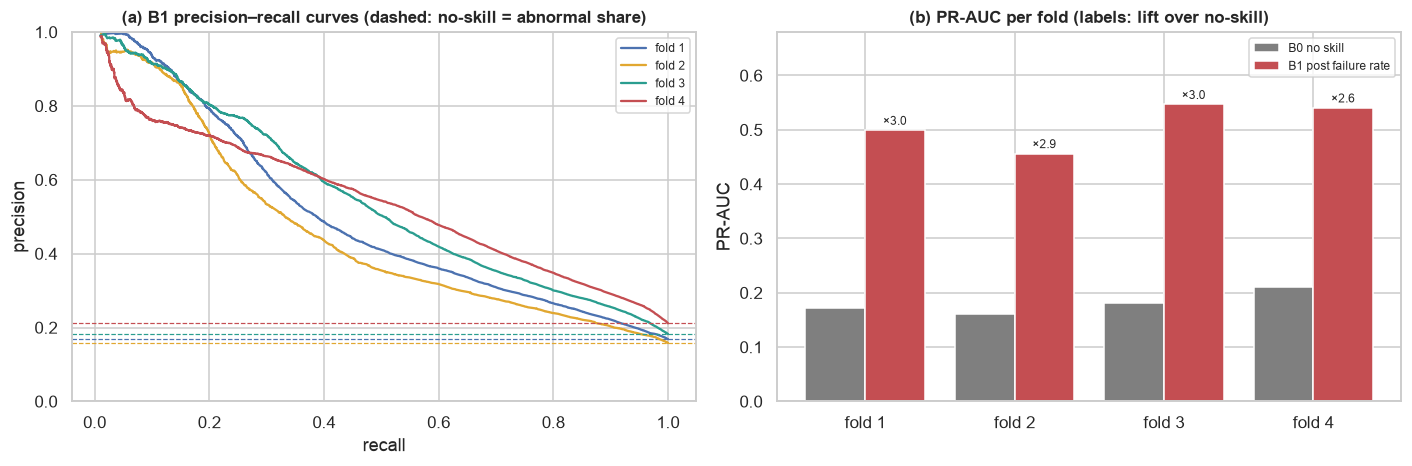

In [24]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4.4))
palette = [C_NORMAL, C_ORANGE, C_GREEN, C_ABN]
for f, color in zip(FOLDS, palette):
    va = df.loc[f["valid"]]
    precision, recall, _ = precision_recall_curve(va[TARGET], va["post_previous_abnormal_rate_7D"])
    keep = recall > 0.01                                        # hide the first few sessions (a handful of ties at the very top)
    axes[0].plot(recall[keep], precision[keep], color=color, label=f"fold {f['fold']}")
    axes[0].axhline(va[TARGET].mean(), color=color, ls="--", lw=.8)
axes[0].set_xlabel("recall"); axes[0].set_ylabel("precision"); axes[0].set_ylim(0, 1)
axes[0].set_title("(a) B1 precision–recall curves (dashed: no-skill = abnormal share)")
axes[0].legend(fontsize=8)
pr = results.pivot(index="fold", columns="baseline", values="PR-AUC")
lift = results[results["baseline"].str.startswith("B1")].set_index("fold")["lift"]
x = np.arange(len(pr))
axes[1].bar(x - .2, pr["B0 no skill"], width=.4, color=C_GREY, label="B0 no skill")
axes[1].bar(x + .2, pr["B1 post failure rate (7 days)"], width=.4, color=C_ABN, label="B1 post failure rate")
for xi, (value, l) in enumerate(zip(pr["B1 post failure rate (7 days)"], lift)):
    axes[1].text(xi + .2, value + .01, f"×{l:.1f}", ha="center", fontsize=8)
axes[1].set_xticks(x); axes[1].set_xticklabels([f"fold {k}" for k in pr.index])
axes[1].set_ylabel("PR-AUC"); axes[1].set_ylim(0, 0.68); axes[1].set_title("(b) PR-AUC per fold (labels: lift over no-skill)")
axes[1].legend(fontsize=8)
fig.tight_layout()
savefig(fig, "09_baselines")

**What we see**

* **(a)** All four curves are far above their dashed no-skill lines (15.8%–21.1%). At low recall the rule is very precise (above 0.8 up to a recall of about 0.1–0.2 in folds 1–3) and precision
  decreases steadily as more failures are demanded, meeting the no-skill line only when almost everything is flagged. **Fold 4 behaves differently**: its top of the ranking is less precise (about 0.72–0.8
  for recalls between 0.05 and 0.3), but its curve is the highest beyond a recall of about 0.45. The top of the list matters most for a small alert budget, so looking at the curves fold by fold is
  more informative than a single pooled number. Fold 2 is the weakest curve over most of the range.
* **(b)** B1 is about three times better than chance in every fold (lift 2.6–3.0), and fold 4 has the lowest lift although its raw PR-AUC is among the highest.

In [25]:
log_decision("9", "Baselines",
             "B0 no skill (random scores, constant training prior, 'always normal') and B1 simple rule: score = post_previous_abnormal_rate_7D (no fitting).",
             "B0 gives PR-AUC = abnormal share and ROC-AUC = 0.5, so the share changes the target a model must beat; B1 is the strongest single start-time signal in Task 1 (§9.4).")

---
## 10. The evaluation protocol

This is the protocol that is fixed **before** hyperparameter optimisation and final model selection. The detail and the evidence are in the sections indicated.

| Element | Decision | Section |
|---------|----------|---------|
| **Problem** | Predict, at the start of a charging session, whether it will end abnormally (13 fault causes against normal or user-stopped endings). Use: ranked risk alerts for monitoring and maintenance prioritisation | 3 |
| **Admissible predictors** | 29 features in 7 groups (calendar, tariff, location, weather, post history, user history, concurrency), built from 27 original columns | 4 |
| **Excluded variables and reasons** | `end_cause`: target only. Energy, cost, service charge, amount, payment, `End Time`, `Payment time`: generated during or after the session. `UserID`: identifier. `Order creation time`: uncertain timing. 10 redundant columns (`electricity_price`, 6 abnormal counts, 2 post no-history flags, `user_no_previous_completed_session`) | 4 |
| **Primary metric** | PR-AUC (average precision), always read with the abnormal share of the fold and as lift | 6 |
| **Complementary metrics** | ROC-AUC, Brier score, log-loss | 6 |
| **Operational measures** | Precision, recall and correct / false / missed alerts per 1,000 sessions at alert budgets of 5%, 10% and 20% | 6 |
| **Baselines** | B0 no skill (PR-AUC = abnormal share, ROC-AUC = 0.5) and B1 recent failure rate of the post | 9 |
| **Temporal strategy** | Burn-in before 2020-04-01. Four expanding-window folds with consecutive validation quarters 2020-Q4 to 2021-Q3, purge of sessions whose label is unknown at the boundary. Test from 2021-10-01 untouched | 7 |
| **Preprocessing** | Everything that learns from data is fitted inside each training fold and applied unchanged to its validation rows; fixed seed | 7.3 |
| **Aggregation and comparison** | Rank by the unweighted mean PR-AUC; also report the weighted mean and the pooled value; stability = std, worst fold and trend; compare fold by fold (paired differences, folds won); no p-values from four folds | 8 |
| **Threshold** | Chosen on the pooled out-of-fold predictions of the four folds, by capacity (alert budget) or by cost ratio after checking calibration; stable across folds; frozen before the test | 7.4 |
| **Final test** | One evaluation of the refitted final model, with the same metrics and the baselines; no changes afterwards | 7.5 |

In [26]:
protocol = {
    "problem": {
        "unit_of_observation": "one charging session (identified by Start Time)",
        "positive_class": "is_Abnormal = 1: end_cause is one of the 13 fault / failure causes",
        "negative_class": "is_Abnormal = 0: 'Charging ends normally' or 'User stops charging'",
        "normal_causes": sorted(NORMAL_CAUSES),
        "prediction_moment": "Start Time of the session",
        "purpose": "ranked risk alerts for preventive monitoring and maintenance prioritisation",
        "target_assumption": "team mapping validated against the dataset's own history columns (Task 1 §5.2); instructor confirmation pending",
    },
    "predictors": {"n_features": len(features), "groups": FEATURE_GROUPS["groups"], "categorical": FEATURE_GROUPS["categorical"]},
    "excluded": classification[classification["category"] != "1 eligible predictor"][["column", "category", "reason"]].to_dict("records"),
    "metrics": {"primary": "PR-AUC (average precision)", "complementary": ["ROC-AUC", "Brier score", "log-loss"],
                "operational": {"alert_budgets": list(ALERT_BUDGETS),
                                "measures": ["precision", "recall", "correct alerts per 1,000", "false alerts per 1,000", "missed per 1,000"]},
                "stability": ["per-fold value", "std across folds", "worst fold", "trend per fold", "folds won against the baseline"],
                "not_used": ["accuracy", "F1", "balanced accuracy", "kappa", "MCC"]},
    "temporal": {"burn_in_end": str(BURN_IN_END.date()), "test_start": str(TEST_START.date()), "seed": SEED,
                 "folds": [{"fold": f["fold"], "train_from": str(BURN_IN_END.date()), "train_before": str(f["lo"].date()),
                            "validate_from": str(f["lo"].date()), "validate_before": str(f["hi"].date()),
                            "train_sessions": len(f["train"]), "purged": f["purged"], "validation_sessions": len(f["valid"])} for f in FOLDS]},
    "aggregation": {"ranking": "unweighted mean of per-fold PR-AUC", "also_reported": ["mean weighted by validation sessions", "pooled"],
                    "stability": ["std across folds", "worst fold", "trend per fold"],
                    "comparison": "paired per-fold differences and folds won; no p-values with four folds"},
    "baselines": {"B0": "random scores / constant training prior / always normal", "B1": "post_previous_abnormal_rate_7D (no fitting)"},
    "threshold_rule": "pooled out-of-fold predictions of the four folds; alert budget or cost-ratio cut-off after calibration check; stable across folds; frozen before test",
    "test_protection": "test rows not loaded in Task 2; final model refitted on all development data with purge; one evaluation; no changes afterwards",
}
(OUT_DIR / "task2_protocol.json").write_text(json.dumps(protocol, indent=2, ensure_ascii=False, default=str))
decision_log = pd.DataFrame(DECISIONS)
decision_log.to_csv(OUT_DIR / "task2_decision_log.csv", index=False)
print("Saved:", OUT_DIR / "task2_protocol.json", "and", OUT_DIR / "task2_decision_log.csv", "| figures in", FIG_DIR)
display(decision_log.style.hide(axis="index").set_properties(**{"text-align": "left", "white-space": "pre-wrap"}))

Saved: prepared/task2_protocol.json and prepared/task2_decision_log.csv | figures in prepared/figures_task2


section,topic,decision,evidence
3,Problem definition,Unit = charging session; positive = abnormal ending (13 fault causes); prediction at Start Time; use = ranked risk alerts for preventive monitoring and maintenance prioritisation.,"Brief, Section 2; target mapping validated against the dataset's own history columns in Task 1 (§5.2), instructor confirmation pending."
4,Predictor set,"27 original columns are eligible (29 features in 7 groups). Excluded: 1 target-only column, 7 generated during or after the session, 12 for other reasons (identifier, uncertain timing, redundancy).",Every one of the 47 columns appears once in the classification table; reasons and evidence per column in Section 4.
5,Error consequences,"A missed failure costs more per event than a false alert, but false alerts are capped by inspection capacity: evaluate the ranking and the result at a fixed alert budget. The cut-off is chosen later from the cost ratio and the capacity.",Failures cluster by post (Task 1 §9.4); best cut-off t* = 1/(1 + c) falls below the abnormal share for c > 4.4.
6,Metrics,"Primary: PR-AUC. Complementary: ROC-AUC, Brier score, log-loss. Operational: precision, recall and correct / false / missed alerts per 1,000 sessions at alert budgets of 5%, 10% and 20%. Stability: per-fold values, std, worst fold, trend, wins against the baseline. Accuracy, F1, kappa and MCC are not used for model comparison.","Abnormal share ~18.5% with unequal error costs; the share moves between periods, so lift and fixed budgets are needed (Sections 5 and 7)."
7,Temporal strategy,Burn-in before 2020-04-01; development 2020-04-01 to 2021-09-30 with four expanding-window folds (validation = consecutive quarters 2020-Q4 to 2021-Q3); test from 2021-10-01 untouched. No random splitting.,"Prevalence, volume and fault mix change over time (Task 1 §7); fold sizes 41.8k–75.8k validation, 111k–271k training; every fold has ≥ 6,600 abnormal sessions."
7,Purge,Training sessions that end after the validation start are removed from that fold's training set.,A label exists only when the session ends (up to 24 h later); 27–39 sessions per fold.
8,Aggregation,"Rank models by the unweighted mean of per-fold PR-AUC; also report the session-weighted mean and the pooled value; stability = std, worst fold and trend; compare models fold by fold (paired differences, folds won). No p-values from four folds.",Periods are the unit of generalisation; abnormal share differs by fold (15.8%–21.1%); the smallest exact Wilcoxon p with 4 folds is 0.125.
9,Baselines,"B0 no skill (random scores, constant training prior, 'always normal') and B1 simple rule: score = post_previous_abnormal_rate_7D (no fitting).","B0 gives PR-AUC = abnormal share and ROC-AUC = 0.5, so the share changes the target a model must beat; B1 is the strongest single start-time signal in Task 1 (§9.4)."


### Limitations and assumptions that remain open

* **Target mapping.** `User stops charging` as a normal ending is a team assumption (checked against the dataset's own columns, not confirmed by the
  instructor). If it changed, the abnormal share, the baselines and every metric would change.
* **Weather** is assumed to be a forecast available at the start, as the brief says. If it is an observed daily value, it contains post-start information.
* **Costs and capacity are unknown.** The cost ratio `c` and the alert budgets (5%, 10%, 20%) are assumptions used to design the protocol. The final threshold needs
  real values or a clearly stated assumption.
* **Four folds** give a rough picture of stability and no valid p-value. Early folds train on less data and without a full winter.
* **The folds are used for selection**, so their scores are slightly optimistic. The test is the unbiased estimate.
* **No post cold-start is tested**: every post of the folds and of the test period was seen in training (Task 1 §11). Cold-start of *users* can be examined
  inside the folds (about 13% of the sessions are from new users).
* **The fault mix changes over time** and the target merges 13 causes. A good average could hide a failure type that the model never detects.

**Next step (Task 3).** Use `temporal_folds`, the metric functions and `prepared/task2_protocol.json` unchanged, fit every candidate inside each training fold,
compare it with B0 and B1 fold by fold, and run the feature-group ablation on the same folds.